In [1]:
# =========================================================
# SECTION 1: INSTALLS & IMPORTS
# =========================================================

!pip install biopython -q

import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from Bio import SeqIO

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm

# =========================================================
# GPU CHECK
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("DEVICE STATUS")
print("="*60)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())
    print("CUDA Version:", torch.version.cuda)

print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.7 MB/s eta 0:00:0000:0100:01
DEVICE STATUS
Device: cuda
GPU: Tesla T4
GPU Count: 2
CUDA Version: 12.8


In [2]:
# =========================================================
# SECTION 2: CONFIGURATION
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MAX_LEN = 512
BATCH_SIZE = 32

EMBED_DIM = 128
HIDDEN_DIM = 256

NUM_LAYERS = 2

LR = 5e-4
EPOCHS = 20

# =========================================================
# DATASET DIRECTORY
# =========================================================

DATA_DIR = "/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset"

FILES = {
    "mab_target": f"{DATA_DIR}/mab_target_sequence.txt",
    "mab_training": f"{DATA_DIR}/mab_training_sequence.txt",
    "p5A_training": f"{DATA_DIR}/p5A_training_sequence.txt",
    "new_targets": f"{DATA_DIR}/New_Target_sequences.txt",
    "scaffold": f"{DATA_DIR}/scaffold_sequence.txt",
    "p15": f"{DATA_DIR}/p15.txt",
    "p18": f"{DATA_DIR}/p18.txt",
}

print("="*60)
print("DATASET FILE CHECK")
print("="*60)

for name, path in FILES.items():
    
    exists = os.path.exists(path)
    
    print(f"{name:<20} -> {exists}")
    
    if exists:
        print(path)

print("="*60)

DATASET FILE CHECK
mab_target           -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/mab_target_sequence.txt
mab_training         -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/mab_training_sequence.txt
p5A_training         -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/p5A_training_sequence.txt
new_targets          -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/New_Target_sequences.txt
scaffold             -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/scaffold_sequence.txt
p15                  -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/p15.txt
p18                  -> True
/kaggle/input/datasets/akashasmaulaaa/protein-scaffold-dataset/p18.txt


In [3]:
# =========================================================
# SECTION 3: FASTA PARSER
# =========================================================

def parse_fasta(filepath):
    
    sequences = []
    
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read().strip()
    
    entries = content.split(">")
    
    for entry in entries:
        
        if len(entry.strip()) == 0:
            continue
        
        lines = entry.split("\n")
        
        header = lines[0].strip()
        
        sequence = "".join(lines[1:])
        
        # cleaning
        sequence = sequence.replace(" ", "")
        sequence = sequence.replace("\ufeff", "")
        sequence = sequence.replace("\n", "")
        sequence = sequence.upper()
        
        sequences.append({
            "header": header,
            "sequence": sequence
        })
    
    return pd.DataFrame(sequences)

print("Parser Ready")

Parser Ready


In [4]:
# =========================================================
# SECTION 4: LOAD ALL DATASETS
# =========================================================

datasets = {}

print("="*70)
print("LOADING DATASETS")
print("="*70)

for name, path in FILES.items():
    
    print(f"\nLoading Dataset: {name}")
    
    df = parse_fasta(path)
    
    datasets[name] = df
    
    print("Shape:", df.shape)
    
    if len(df) > 0:
        
        print("\nFirst Header:")
        print(df.iloc[0]["header"])
        
        print("\nFirst Sequence Preview:")
        print(df.iloc[0]["sequence"][:120])
        
        print("\nSequence Length:")
        print(len(df.iloc[0]["sequence"]))
    
    print("-"*70)

print("\nAll datasets loaded successfully.")

LOADING DATASETS

Loading Dataset: mab_target
Shape: (1, 2)

First Header:
1CE1:L CAMPATH-1H:Light Chain 1

First Sequence Preview:
DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKLLIYNTNNLQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCLQHISRPRTFGQGTKVEIKRTVAAPSVFIFPP

Sequence Length:
214
----------------------------------------------------------------------

Loading Dataset: mab_training
Shape: (1000, 2)

First Header:
1CE1_L Chain L, Protein (campath-1h:light Chain) [Homo sapiens]

First Sequence Preview:
DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKLLIYNTNNLQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCLQHISRPRTFGQGTKVEIKRTVAAPSVFIFPP

Sequence Length:
211
----------------------------------------------------------------------

Loading Dataset: p5A_training
Shape: (1000, 2)

First Header:
6MVL_L Chain L, Antibody Fab fragment light chain [Homo sapiens]

First Sequence Preview:
EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPRLLIYGASSRATGIPDRFSGSGSGTDFTLTISRLEPEDFAVYYCQQYGSSPFTFGPGTKVDIKRTVAAPSVFIFP

Sequence Leng

In [5]:
# =========================================================
# SECTION 5: DATA ANALYSIS
# =========================================================

print("="*70)
print("DATASET ANALYSIS")
print("="*70)

for name, df in datasets.items():
    
    print(f"\n{name.upper()}")
    print("-"*70)
    
    lengths = df["sequence"].apply(len)
    
    print("Total Sequences :", len(df))
    print("Min Length      :", lengths.min())
    print("Max Length      :", lengths.max())
    print("Mean Length     :", round(lengths.mean(), 2))
    
    # gap analysis
    gap_count = df["sequence"].str.contains("-").sum()
    
    print("Sequences With Gaps :", gap_count)
    
    print("\nExample:")
    print(df.iloc[0]["sequence"][:150])
    
    print("\n")

DATASET ANALYSIS

MAB_TARGET
----------------------------------------------------------------------
Total Sequences : 1
Min Length      : 214
Max Length      : 214
Mean Length     : 214.0
Sequences With Gaps : 0

Example:
DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKLLIYNTNNLQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCLQHISRPRTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKV



MAB_TRAINING
----------------------------------------------------------------------
Total Sequences : 1000
Min Length      : 206
Max Length      : 449
Mean Length     : 218.38
Sequences With Gaps : 0

Example:
DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKLLIYNTNNLQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCLQHISRPRTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKV



P5A_TRAINING
----------------------------------------------------------------------
Total Sequences : 1000
Min Length      : 193
Max Length      : 764
Mean Length     : 221.55
Sequences With Gaps : 0

Example:
EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPRLLIY

In [6]:
# =========================================================
# SECTION 6: GAP EXTRACTION ENGINE
# =========================================================

def extract_gaps(scaffold_seq, target_seq, context_window=25):
    
    results = []
    
    i = 0
    
    while i < len(scaffold_seq):
        
        # detect gap start
        if scaffold_seq[i] == "-":
            
            start = i
            
            while i < len(scaffold_seq) and scaffold_seq[i] == "-":
                i += 1
            
            end = i
            
            # true missing sequence from target
            gap_sequence = target_seq[start:end]
            
            # left context
            left_start = max(0, start - context_window)
            left_context = target_seq[left_start:start]
            
            # right context
            right_end = min(len(target_seq), end + context_window)
            right_context = target_seq[end:right_end]
            
            results.append({
                "gap_start": start,
                "gap_end": end,
                "gap_size": end - start,
                "gap_sequence": gap_sequence,
                "left_context": left_context,
                "right_context": right_context
            })
        
        else:
            i += 1
    
    return pd.DataFrame(results)

In [7]:
# =========================================================
# SECTION 7: APPLY GAP EXTRACTION
# =========================================================

scaffold_seq = datasets["scaffold"].iloc[0]["sequence"]

target_seq = datasets["mab_target"].iloc[0]["sequence"]

gap_df = extract_gaps(scaffold_seq, target_seq)

print("="*70)
print("EXTRACTED GAPS")
print("="*70)

print("Total Gaps Found:", len(gap_df))

display(gap_df)

EXTRACTED GAPS
Total Gaps Found: 6


,gap_start,gap_end,gap_size,gap_sequence,left_context,right_context
0,0,3,3,DIQ,,MTQSPSSLSASVGDRVTITCKASQN
1,24,27,3,ASQ,DIQMTQSPSSLSASVGDRVTITCK,NIDKYLNWYQQKPGKAPKLLIYNTN
2,62,65,3,SGS,QKPGKAPKLLIYNTNNLQTGVPSRF,GSGTDFTFTISSLQPEDIATYYCLQ
3,66,70,4,SGTD,KAPKLLIYNTNNLQTGVPSRFSGSG,FTFTISSLQPEDIATYYCLQHISRP
4,75,86,11,SSLQPEDIATY,TNNLQTGVPSRFSGSGSGTDFTFTI,YCLQHISRPRTFGQGTKVEIKRTVA
5,210,214,4,RGEC,YEKHKVYACEVTHQGLSSPVTKSFN,


In [8]:
# =========================================================
# SECTION 8: SCAFFOLD RECONSTRUCTION PREVIEW
# =========================================================

print("="*70)
print("SCAFFOLD")
print("="*70)

print(scaffold_seq)

print("\n")

print("="*70)
print("TARGET")
print("="*70)

print(target_seq)

print("\n")

print("="*70)
print("GAP DETAILS")
print("="*70)

for idx, row in gap_df.iterrows():
    
    print(f"\nGap #{idx+1}")
    
    print("Start Position :", row["gap_start"])
    print("End Position   :", row["gap_end"])
    print("Gap Size       :", row["gap_size"])
    
    print("Gap Sequence   :", row["gap_sequence"])
    
    print("Left Context   :", row["left_context"])
    print("Right Context  :", row["right_context"])

SCAFFOLD
---MTQSPSSISASVGDRVTITCK---NIDKYINWYQQKPGKAPKIIIYNTNNIQTGVPSRF---G----FTFTI-----------YCIQHISRPRTFGQGTKVEIKRSIAAPSVFIFPPSDEQIKSGTASVVCIINNFYPREAQPRRKVDNAIQSGNSQESVTEQDSKDSTYSISSTITISKADYEKHKVYACEVTHQGISSPVTKSFN----


TARGET
DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKLLIYNTNNLQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCLQHISRPRTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC


GAP DETAILS

Gap #1
Start Position : 0
End Position   : 3
Gap Size       : 3
Gap Sequence   : DIQ
Left Context   : 
Right Context  : MTQSPSSLSASVGDRVTITCKASQN

Gap #2
Start Position : 24
End Position   : 27
Gap Size       : 3
Gap Sequence   : ASQ
Left Context   : DIQMTQSPSSLSASVGDRVTITCK
Right Context  : NIDKYLNWYQQKPGKAPKLLIYNTN

Gap #3
Start Position : 62
End Position   : 65
Gap Size       : 3
Gap Sequence   : SGS
Left Context   : QKPGKAPKLLIYNTNNLQTGVPSRF
Right Context  : GSGTDFTFTISSLQPEDIATYYCLQ

Gap #4
Start Position : 66
End Position   :

In [9]:
# =========================================================
# SECTION 9A: CUSTOM LARGE GAP SIZES
# =========================================================

gap_sizes = [3, 5, 7, 10, 15, 20]

print("="*60)
print("CUSTOM GAP SIZE DISTRIBUTION")
print("="*60)

print(gap_sizes)

CUSTOM GAP SIZE DISTRIBUTION
[3, 5, 7, 10, 15, 20]


In [10]:
# =========================================================
# SECTION 9B: BUILD TRAINING DATASET
# =========================================================

def create_training_samples(sequence, gap_sizes, context_window=25):
    
    samples = []
    
    seq_len = len(sequence)
    
    for gap_size in gap_sizes:
        
        for start in range(context_window, seq_len - gap_size - context_window):
            
            end = start + gap_size
            
            gap_seq = sequence[start:end]
            
            left_context = sequence[start-context_window:start]
            
            right_context = sequence[end:end+context_window]
            
            masked_sequence = (
                left_context +
                ("-" * gap_size) +
                right_context
            )
            
            samples.append({
                "left_context": left_context,
                "right_context": right_context,
                "gap_sequence": gap_seq,
                "gap_size": gap_size,
                "masked_sequence": masked_sequence
            })
    
    return samples

In [11]:
# =========================================================
# SECTION 9C: GENERATE FULL TRAINING DATASET
# =========================================================

training_sources = [
    "mab_training",
    "p5A_training",
    "p15",
    "p18"
]

all_samples = []

for source in training_sources:
    
    print(f"\nProcessing: {source}")
    
    df = datasets[source]
    
    for seq in tqdm(df["sequence"]):
        
        samples = create_training_samples(
            sequence=seq,
            gap_sizes=gap_sizes,
            context_window=25
        )
        
        all_samples.extend(samples)

training_df = pd.DataFrame(all_samples)

print("\n" + "="*70)
print("FINAL TRAINING DATASET")
print("="*70)

print("Total Samples:", len(training_df))

display(training_df.head())


Processing: mab_training


100%|██████████| 1000/1000 [00:00<00:00, 1249.80it/s]



Processing: p5A_training


100%|██████████| 1000/1000 [00:00<00:00, 1224.49it/s]



Processing: p15


100%|██████████| 1000/1000 [00:00<00:00, 1240.32it/s]



Processing: p18


100%|██████████| 1000/1000 [00:00<00:00, 1191.98it/s]



FINAL TRAINING DATASET
Total Samples: 3826728


,left_context,right_context,gap_sequence,gap_size,masked_sequence
0,DIQMTQSPSSLSASVGDRVTITCKA,IDKYLNWYQQKPGKAPKLLIYNTNN,SQN,3,DIQMTQSPSSLSASVGDRVTITCKA---IDKYLNWYQQKPGKAPKL...
1,IQMTQSPSSLSASVGDRVTITCKAS,DKYLNWYQQKPGKAPKLLIYNTNNL,QNI,3,IQMTQSPSSLSASVGDRVTITCKAS---DKYLNWYQQKPGKAPKLL...
2,QMTQSPSSLSASVGDRVTITCKASQ,KYLNWYQQKPGKAPKLLIYNTNNLQ,NID,3,QMTQSPSSLSASVGDRVTITCKASQ---KYLNWYQQKPGKAPKLLI...
3,MTQSPSSLSASVGDRVTITCKASQN,YLNWYQQKPGKAPKLLIYNTNNLQT,IDK,3,MTQSPSSLSASVGDRVTITCKASQN---YLNWYQQKPGKAPKLLIY...
4,TQSPSSLSASVGDRVTITCKASQNI,LNWYQQKPGKAPKLLIYNTNNLQTG,DKY,3,TQSPSSLSASVGDRVTITCKASQNI---LNWYQQKPGKAPKLLIYN...


In [12]:
# =========================================================
# SECTION 10A: REMOVE DUPLICATES
# =========================================================

print("="*60)
print("BEFORE DEDUPLICATION")
print("="*60)

print("Samples:", len(training_df))

training_df = training_df.drop_duplicates()

print("\n")

print("="*60)
print("AFTER DEDUPLICATION")
print("="*60)

print("Samples:", len(training_df))

BEFORE DEDUPLICATION
Samples: 3826728


AFTER DEDUPLICATION
Samples: 892806


In [13]:
# =========================================================
# SECTION 10B: SMART SAMPLING
# =========================================================

MAX_SAMPLES = 200000

if len(training_df) > MAX_SAMPLES:
    
    training_df = training_df.sample(
        n=MAX_SAMPLES,
        random_state=42
    ).reset_index(drop=True)

print("="*60)
print("FINAL TRAINING SIZE")
print("="*60)

print("Samples:", len(training_df))

FINAL TRAINING SIZE
Samples: 200000


In [14]:
# =========================================================
# SECTION 10C: AMINO ACID TOKENIZER
# =========================================================

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

aa_to_idx = {
    aa: idx + 1
    for idx, aa in enumerate(AMINO_ACIDS)
}

aa_to_idx["-"] = 21
aa_to_idx["PAD"] = 0

idx_to_aa = {
    v: k
    for k, v in aa_to_idx.items()
}

print("="*60)
print("VOCABULARY")
print("="*60)

print(aa_to_idx)

VOCABULARY
{'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20, '-': 21, 'PAD': 0}


In [15]:
# =========================================================
# SECTION 10D: TOKENIZATION FUNCTIONS
# =========================================================

def encode_sequence(sequence, max_len):
    
    encoded = [
        aa_to_idx.get(aa, 0)
        for aa in sequence
    ]
    
    if len(encoded) < max_len:
        
        encoded += [0] * (max_len - len(encoded))
    
    else:
        encoded = encoded[:max_len]
    
    return encoded


def decode_sequence(encoded):
    
    return "".join([
        idx_to_aa.get(idx, "")
        for idx in encoded
        if idx != 0
    ])

print("Tokenizer Ready")

Tokenizer Ready


In [16]:
# =========================================================
# SECTION 10E: ENCODE INPUT SEQUENCES
# =========================================================

training_df["input_sequence"] = training_df.apply(
    lambda row:
        row["left_context"] +
        ("-" * int(row["gap_size"])) +
        row["right_context"],
    axis=1
)

MAX_INPUT_LEN = training_df["input_sequence"].apply(len).max()

print("="*60)
print("MAX INPUT LENGTH")
print("="*60)

print(MAX_INPUT_LEN)

# =========================================================
# ENCODE INPUTS
# =========================================================

training_df["encoded_input"] = training_df["input_sequence"].apply(
    lambda x: encode_sequence(x, MAX_INPUT_LEN)
)

print("\nEncoding Complete")

print("\nExample Input Sequence:\n")

print(training_df.iloc[0]["input_sequence"])

print("\nEncoded Version:\n")

print(training_df.iloc[0]["encoded_input"][:50])

MAX INPUT LENGTH
70

Encoding Complete

Example Input Sequence:

LLIYSAYFLYSGVPSRFSGSRSGTD---TISSLQPEDFATYYCQQYSRYSPVT

Encoded Version:

[10, 10, 8, 20, 16, 1, 20, 5, 10, 20, 16, 6, 18, 13, 16, 15, 5, 16, 6, 16, 15, 16, 6, 17, 3, 21, 21, 21, 17, 8, 16, 16, 10, 14, 13, 4, 3, 5, 1, 17, 20, 20, 2, 14, 14, 20, 16, 15, 20, 16]


In [17]:
# =========================================================
# SECTION 10F: ENCODE TARGETS
# =========================================================

MAX_GAP_LEN = training_df["gap_size"].max()

print("="*60)
print("MAX GAP LENGTH")
print("="*60)

print(MAX_GAP_LEN)

training_df["encoded_target"] = training_df["gap_sequence"].apply(
    lambda x: encode_sequence(x, MAX_GAP_LEN)
)

print("\nTarget Encoding Complete")

MAX GAP LENGTH
20

Target Encoding Complete


In [18]:
# =========================================================
# SECTION 10G: FINAL DATA PREVIEW
# =========================================================

print("="*70)
print("FINAL TRAINING DATASET")
print("="*70)

display(
    training_df[
        [
            "input_sequence",
            "gap_sequence",
            "encoded_input",
            "encoded_target"
        ]
    ].head()
)

FINAL TRAINING DATASET


,input_sequence,gap_sequence,encoded_input,encoded_target
0,LLIYSAYFLYSGVPSRFSGSRSGTD---TISSLQPEDFATYYCQQY...,FTL,"[10, 10, 8, 20, 16, 1, 20, 5, 10, 20, 16, 6, 1...","[5, 17, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,GSGTDFTLTISSLQPEDFATYYCQQ---------------IKRTVA...,GNSFPYTFGQGTNLE,"[6, 16, 6, 17, 3, 5, 17, 10, 17, 8, 16, 16, 10...","[6, 12, 16, 5, 13, 20, 17, 5, 6, 14, 6, 17, 12..."
2,YYCQQYISYHEPITFGQGTKVEIKR-------FIFPPSDSQLKSGT...,TVAAPSV,"[20, 20, 2, 14, 14, 20, 8, 16, 20, 7, 4, 13, 8...","[17, 18, 1, 1, 13, 16, 18, 0, 0, 0, 0, 0, 0, 0..."
3,FAVYYCQQGSNWPPVTFGQGTKLEI--------------------S...,KRTVAAPSVFIFPPSDEQLK,"[5, 1, 18, 20, 20, 2, 14, 14, 6, 16, 12, 19, 1...","[9, 15, 17, 18, 1, 1, 13, 16, 18, 5, 8, 5, 13,..."
4,QKPGKAPKLLIYGASNRYTGVPSRF---GSGTDFTLTISSLQPDDF...,SGS,"[14, 9, 13, 6, 9, 1, 13, 9, 10, 10, 8, 20, 6, ...","[16, 6, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."


In [19]:
# =========================================================
# SECTION 11A: SMALL RF DATASET
# =========================================================

RF_SAMPLES = 50000

rf_df = training_df.sample(
    n=RF_SAMPLES,
    random_state=42
).reset_index(drop=True)

print("="*60)
print("RF DATASET")
print("="*60)

print("Samples:", len(rf_df))

RF DATASET
Samples: 50000


In [20]:
# =========================================================
# SECTION 11B: LABEL ENCODING
# =========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

rf_df["target_label"] = label_encoder.fit_transform(
    rf_df["gap_sequence"]
)

print("="*60)
print("UNIQUE LABELS")
print("="*60)

print(rf_df["target_label"].nunique())

UNIQUE LABELS
20312


In [21]:
# =========================================================
# SECTION 11C: FEATURES
# =========================================================

X = np.array(
    rf_df["encoded_input"].tolist(),
    dtype=np.int16
)

y = np.array(
    rf_df["target_label"].tolist(),
    dtype=np.int32
)

print("="*60)
print("FEATURE SHAPES")
print("="*60)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

FEATURE SHAPES
X Shape: (50000, 70)
y Shape: (50000,)


In [22]:
# =========================================================
# SECTION 11D: TRAIN TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

TRAIN TEST SPLIT
Train: (40000, 70)
Test : (10000, 70)


In [23]:
# =========================================================
# SECTION 11E: SAFE RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=12,
    n_jobs=2,
    random_state=42,
    verbose=1
)

print("="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

rf_model.fit(X_train, y_train)

print("\nTraining Complete")

TRAINING RANDOM FOREST


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



Training Complete


[Parallel(n_jobs=2)]: Done  20 out of  20 | elapsed:   11.9s finished


In [24]:
# =========================================================
# SECTION 11F: EVALUATION
# =========================================================

preds = rf_model.predict(X_test)

acc = accuracy_score(y_test, preds)

print("="*60)
print("RF RESULTS")
print("="*60)

print("Accuracy:", round(acc, 4))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  20 out of  20 | elapsed:    7.8s finished


RF RESULTS
Accuracy: 0.3699


In [25]:
# =========================================================
# SECTION 12A: TRAIN VALID SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    training_df,
    test_size=0.1,
    random_state=42
)

print("="*60)
print("TRAIN VALID SPLIT")
print("="*60)

print("Train Samples:", len(train_df))
print("Valid Samples:", len(valid_df))

TRAIN VALID SPLIT
Train Samples: 180000
Valid Samples: 20000


In [26]:
# =========================================================
# SECTION 12B: PYTORCH DATASET
# =========================================================

from torch.utils.data import Dataset, DataLoader

class PSGFDataset(Dataset):
    
    def __init__(self, dataframe):
        
        self.inputs = dataframe["encoded_input"].tolist()
        self.targets = dataframe["encoded_target"].tolist()
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, idx):
        
        x = torch.tensor(
            self.inputs[idx],
            dtype=torch.long
        )
        
        y = torch.tensor(
            self.targets[idx],
            dtype=torch.long
        )
        
        return x, y

print("Dataset Class Ready")

Dataset Class Ready


In [27]:
# =========================================================
# SECTION 12C: DATALOADERS
# =========================================================

train_dataset = PSGFDataset(train_df)

valid_dataset = PSGFDataset(valid_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("="*60)
print("DATALOADERS READY")
print("="*60)

print("Train Batches:", len(train_loader))
print("Valid Batches:", len(valid_loader))

DATALOADERS READY
Train Batches: 2813
Valid Batches: 313


In [28]:
# =========================================================
# SECTION 13A: BILSTM MODEL
# =========================================================

class BiLSTMGapPredictor(nn.Module):
    
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        output_dim,
        num_layers=2,
        dropout=0.3
    ):
        
        super().__init__()
        
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )
        
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        
        self.dropout = nn.Dropout(dropout)
        
        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim * MAX_GAP_LEN
        )
        
        self.output_dim = output_dim
    
    def forward(self, x):
        
        x = self.embedding(x)
        
        outputs, (hidden, cell) = self.lstm(x)
        
        # use last timestep
        x = outputs[:, -1, :]
        
        x = self.dropout(x)
        
        x = self.fc(x)
        
        x = x.view(
            x.size(0),
            MAX_GAP_LEN,
            self.output_dim
        )
        
        return x

In [29]:
# =========================================================
# SECTION 13B: INITIALIZE MODEL
# =========================================================

VOCAB_SIZE = len(aa_to_idx)

OUTPUT_DIM = VOCAB_SIZE

model = BiLSTMGapPredictor(
    vocab_size=VOCAB_SIZE,
    embed_dim=192,
    hidden_dim=384,
    output_dim=OUTPUT_DIM,
    num_layers=2,
    dropout=0.3
)

model = model.to(device)

print("="*60)
print("MODEL INITIALIZED")
print("="*60)

print(model)

MODEL INITIALIZED
BiLSTMGapPredictor(
  (embedding): Embedding(22, 192, padding_idx=0)
  (lstm): LSTM(192, 384, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=768, out_features=440, bias=True)
)


In [30]:
# =========================================================
# SECTION 13C: LOSS & OPTIMIZER
# =========================================================

criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("="*60)
print("LOSS & OPTIMIZER READY")
print("="*60)

LOSS & OPTIMIZER READY


In [31]:
# =========================================================
# SECTION 14A: TRAIN FUNCTION WITH MIXED PRECISION
# =========================================================

scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader):
    
    model.train()
    
    total_loss = 0
    
    correct_tokens = 0
    total_tokens = 0
    
    loop = tqdm(loader)
    
    for inputs, targets in loop:
        
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        # =====================================================
        # MIXED PRECISION
        # =====================================================
        
        with torch.cuda.amp.autocast():
            
            outputs = model(inputs)
            
            loss = criterion(
                outputs.view(-1, VOCAB_SIZE),
                targets.view(-1)
            )
        
        # =====================================================
        # BACKPROP
        # =====================================================
        
        scaler.scale(loss).backward()
        
        # =====================================================
        # GRADIENT CLIPPING
        # =====================================================
        
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        
        scaler.step(optimizer)
        
        scaler.update()
        
        total_loss += loss.item()
        
        # =====================================================
        # TOKEN ACCURACY
        # =====================================================
        
        preds = outputs.argmax(dim=-1)
        
        mask = targets != 0
        
        correct_tokens += (
            ((preds == targets) & mask)
            .sum()
            .item()
        )
        
        total_tokens += mask.sum().item()
        
        token_acc = correct_tokens / total_tokens
        
        loop.set_postfix(
            loss=round(loss.item(), 4),
            token_acc=round(token_acc, 4)
        )
    
    avg_loss = total_loss / len(loader)
    
    avg_acc = correct_tokens / total_tokens
    
    return avg_loss, avg_acc

In [32]:
# =========================================================
# SECTION 14B: VALIDATION FUNCTION WITH ACCURACY
# =========================================================

def validate(model, loader):
    
    model.eval()
    
    total_loss = 0
    
    correct_tokens = 0
    total_tokens = 0
    
    with torch.no_grad():
        
        for inputs, targets in loader:
            
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            
            loss = criterion(
                outputs.view(-1, VOCAB_SIZE),
                targets.view(-1)
            )
            
            total_loss += loss.item()
            
            # =================================================
            # TOKEN ACCURACY
            # =================================================
            
            preds = outputs.argmax(dim=-1)
            
            mask = targets != 0
            
            correct_tokens += (
                (preds == targets) & mask
            ).sum().item()
            
            total_tokens += mask.sum().item()
    
    avg_loss = total_loss / len(loader)
    
    avg_acc = correct_tokens / total_tokens
    
    return avg_loss, avg_acc

In [33]:
# =========================================================
# SECTION 14C: FULL TRAINING LOOP
# =========================================================

EPOCHS = 20

best_valid_acc = 0

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

print("="*70)
print("STARTING TRAINING")
print("="*70)

for epoch in range(EPOCHS):
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # =====================================================
    # TRAIN
    # =====================================================
    
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )
    
    # =====================================================
    # VALIDATE
    # =====================================================
    
    valid_loss, valid_acc = validate(
        model,
        valid_loader
    )
    
    # =====================================================
    # STORE HISTORY
    # =====================================================
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)
    
    # =====================================================
    # PRINT METRICS
    # =====================================================
    
    print(f"\nTrain Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")
    
    print(f"\nValid Loss     : {valid_loss:.4f}")
    print(f"Valid Accuracy : {valid_acc:.4f}")
    
    # =====================================================
    # SAVE BEST MODEL
    # =====================================================
    
    if valid_acc > best_valid_acc:
        
        best_valid_acc = valid_acc
        
        torch.save(
            model.state_dict(),
            "best_bilstm_model.pth"
        )
        
        print("\nBest Accuracy Model Saved")

STARTING TRAINING

Epoch 1/20


100%|██████████| 2813/2813 [00:50<00:00, 55.60it/s, loss=0.859, token_acc=0.59] 



Train Loss     : 1.3600
Train Accuracy : 0.5897

Valid Loss     : 0.7644
Valid Accuracy : 0.7978

Best Accuracy Model Saved

Epoch 2/20


100%|██████████| 2813/2813 [00:50<00:00, 56.07it/s, loss=0.632, token_acc=0.773]



Train Loss     : 0.8240
Train Accuracy : 0.7735

Valid Loss     : 0.6864
Valid Accuracy : 0.8121

Best Accuracy Model Saved

Epoch 3/20


...


Train Loss     : 0.3775
Train Accuracy : 0.9028

Valid Loss     : 0.3788
Valid Accuracy : 0.9043

Best Accuracy Model Saved

Epoch 19/20


100%|██████████| 2813/2813 [00:52<00:00, 53.33it/s, loss=0.386, token_acc=0.906]



Train Loss     : 0.3590
Train Accuracy : 0.9065

Valid Loss     : 0.3746
Valid Accuracy : 0.9054

Best Accuracy Model Saved

Epoch 20/20


100%|██████████| 2813/2813 [00:52<00:00, 53.63it/s, loss=0.267, token_acc=0.907]



Train Loss     : 0.3569
Train Accuracy : 0.9070

Valid Loss     : 0.3686
Valid Accuracy : 0.9066

Best Accuracy Model Saved


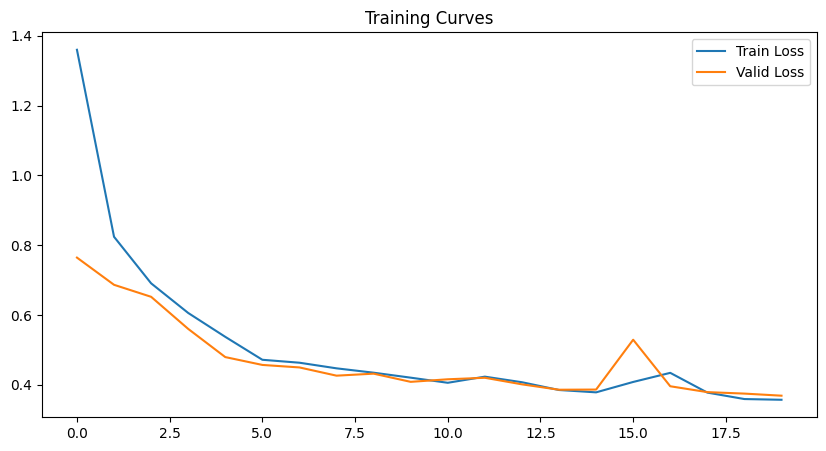

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")

plt.legend()
plt.title("Training Curves")

plt.show()

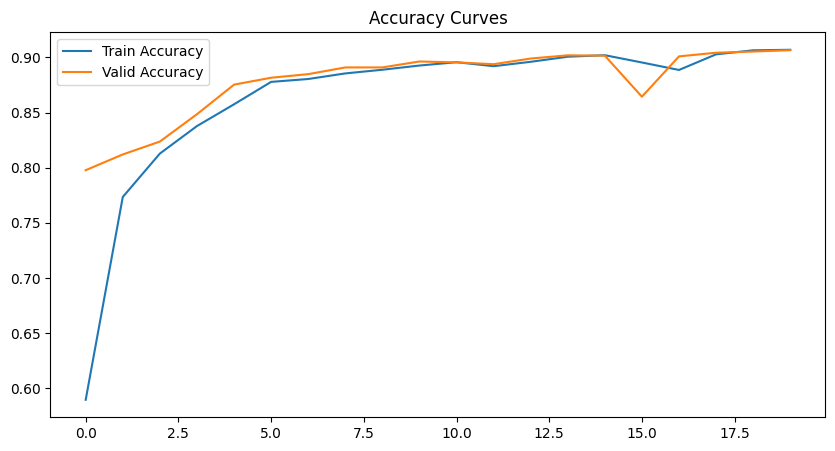

In [35]:
plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(valid_accuracies, label="Valid Accuracy")

plt.legend()
plt.title("Accuracy Curves")

plt.show()

In [36]:
# =========================================================
# SECTION 15A: LOAD BEST MODEL
# =========================================================

model.load_state_dict(
    torch.load(
        "best_bilstm_model.pth",
        map_location=device
    )
)

model.eval()

print("="*60)
print("BEST MODEL LOADED")
print("="*60)

BEST MODEL LOADED


In [37]:
# =========================================================
# SECTION 15B: GAP PREDICTION FUNCTION
# =========================================================

def predict_gap(
    left_context,
    right_context,
    gap_size
):
    
    input_seq = (
        left_context +
        ("-" * gap_size) +
        right_context
    )
    
    encoded = encode_sequence(
        input_seq,
        MAX_INPUT_LEN
    )
    
    x = torch.tensor(
        [encoded],
        dtype=torch.long
    ).to(device)
    
    with torch.no_grad():
        
        outputs = model(x)
        
        preds = outputs.argmax(dim=-1)
        
        preds = preds[0][:gap_size].cpu().numpy()
    
    predicted_gap = decode_sequence(preds)
    
    return predicted_gap

In [38]:
# =========================================================
# SECTION 15C: REAL SCAFFOLD PREDICTION
# =========================================================

predictions = []

print("="*70)
print("REAL PSGF GAP PREDICTIONS")
print("="*70)

for idx, row in gap_df.iterrows():
    
    predicted_gap = predict_gap(
        row["left_context"],
        row["right_context"],
        row["gap_size"]
    )
    
    predictions.append(predicted_gap)
    
    print(f"\nGap #{idx+1}")
    
    print("-"*50)
    
    print("Gap Size        :", row["gap_size"])
    
    print("True Gap        :", row["gap_sequence"])
    
    print("Predicted Gap   :", predicted_gap)
    
    print("Match           :", predicted_gap == row["gap_sequence"])

REAL PSGF GAP PREDICTIONS

Gap #1
--------------------------------------------------
Gap Size        : 3
True Gap        : DIQ
Predicted Gap   : SQS
Match           : False

Gap #2
--------------------------------------------------
Gap Size        : 3
True Gap        : ASQ
Predicted Gap   : SQD
Match           : False

Gap #3
--------------------------------------------------
Gap Size        : 3
True Gap        : SGS
Predicted Gap   : SGS
Match           : True

Gap #4
--------------------------------------------------
Gap Size        : 4
True Gap        : SGTD
Predicted Gap   : SGTD
Match           : True

Gap #5
--------------------------------------------------
Gap Size        : 11
True Gap        : SSLQPEDIATY
Predicted Gap   : SSLQPEDIATY
Match           : True

Gap #6
--------------------------------------------------
Gap Size        : 4
True Gap        : RGEC
Predicted Gap   : RGEC
Match           : True


In [39]:
# =========================================================
# SECTION 15D: FULL SEQUENCE RECONSTRUCTION
# =========================================================

reconstructed = list(scaffold_seq)

for idx, row in gap_df.iterrows():
    
    pred_gap = predictions[idx]
    
    start = row["gap_start"]
    end = row["gap_end"]
    
    for i, aa in enumerate(pred_gap):
        
        reconstructed[start + i] = aa

reconstructed_sequence = "".join(reconstructed)

print("="*70)
print("RECONSTRUCTED SEQUENCE")
print("="*70)

print(reconstructed_sequence)

print("\n")

print("="*70)
print("GROUND TRUTH")
print("="*70)

print(target_seq)

RECONSTRUCTED SEQUENCE
SQSMTQSPSSISASVGDRVTITCKSQDNIDKYINWYQQKPGKAPKIIIYNTNNIQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCIQHISRPRTFGQGTKVEIKRSIAAPSVFIFPPSDEQIKSGTASVVCIINNFYPREAQPRRKVDNAIQSGNSQESVTEQDSKDSTYSISSTITISKADYEKHKVYACEVTHQGISSPVTKSFNRGEC


GROUND TRUTH
DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKLLIYNTNNLQTGVPSRFSGSGSGTDFTFTISSLQPEDIATYYCLQHISRPRTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC


In [40]:
# =========================================================
# SECTION 15E: FINAL RECONSTRUCTION METRICS
# =========================================================

correct = 0

for a, b in zip(
    reconstructed_sequence,
    target_seq
):
    
    if a == b:
        correct += 1

residue_accuracy = correct / len(target_seq)

print("="*70)
print("FINAL PSGF RESULTS")
print("="*70)

print("Residue Accuracy:",
      round(residue_accuracy, 4))

exact_match = (
    reconstructed_sequence == target_seq
)

print("Exact Reconstruction:",
      exact_match)

FINAL PSGF RESULTS
Residue Accuracy: 0.8785
Exact Reconstruction: False


In [41]:
# =========================================================
# SECTION 16A: GAP-WISE ANALYSIS
# =========================================================

results = []

print("="*80)
print("DETAILED GAP ANALYSIS")
print("="*80)

for idx, row in gap_df.iterrows():
    
    true_gap = row["gap_sequence"]
    
    pred_gap = predictions[idx]
    
    # residue match
    matches = sum(
        a == b
        for a, b in zip(true_gap, pred_gap)
    )
    
    residue_acc = matches / len(true_gap)
    
    results.append({
        "gap_id": idx + 1,
        "gap_size": row["gap_size"],
        "true_gap": true_gap,
        "pred_gap": pred_gap,
        "residue_accuracy": residue_acc,
        "exact_match": true_gap == pred_gap
    })
    
    print(f"\nGap #{idx+1}")
    print("-"*60)
    
    print("Gap Size        :", row["gap_size"])
    print("True Gap        :", true_gap)
    print("Predicted Gap   :", pred_gap)
    
    print("Residue Accuracy:",
          round(residue_acc, 4))
    
    print("Exact Match     :",
          true_gap == pred_gap)

gap_results_df = pd.DataFrame(results)

DETAILED GAP ANALYSIS

Gap #1
------------------------------------------------------------
Gap Size        : 3
True Gap        : DIQ
Predicted Gap   : SQS
Residue Accuracy: 0.0
Exact Match     : False

Gap #2
------------------------------------------------------------
Gap Size        : 3
True Gap        : ASQ
Predicted Gap   : SQD
Residue Accuracy: 0.0
Exact Match     : False

Gap #3
------------------------------------------------------------
Gap Size        : 3
True Gap        : SGS
Predicted Gap   : SGS
Residue Accuracy: 1.0
Exact Match     : True

Gap #4
------------------------------------------------------------
Gap Size        : 4
True Gap        : SGTD
Predicted Gap   : SGTD
Residue Accuracy: 1.0
Exact Match     : True

Gap #5
------------------------------------------------------------
Gap Size        : 11
True Gap        : SSLQPEDIATY
Predicted Gap   : SSLQPEDIATY
Residue Accuracy: 1.0
Exact Match     : True

Gap #6
-----------------------------------------------------------